# Cell selection: 5D ntuples vs Calo ntuples

The two ntuple formats select **completely different cells**:

- **Calo ntuples** store *all* 187,652 calorimeter cells every event, plus the full
  topocluster -> cell association (`cluster_to_cell_indices`).
- **5D ntuples** store a *thinned* subset (~400-800 cells/event). The nominal
  upstream AOD thinning (per earlier discussion) keeps cells associated with
  **electron/photon, muon and tau** objects **plus the Tile D-layer cells**.
  We test that story against the data below — and the data tells a different one.

This notebook quantifies the resulting bias:

1. **Layer occupancy** — how many cells per event each format populates in each
   sampling layer, and what fraction of the layer's cells that is.
2. **Layer distribution: topocluster cells vs 5D cells** — if you trained on 5D
   cells expecting topocluster-like coverage, this is the sampling-layer bias
   you would inherit.

The two files are different event samples (both ttbar), so we compare per-event
averages / normalized distributions, not cell-by-cell.

In [1]:
import glob
import numpy as np
import awkward as ak
import uproot
%matplotlib inline
import matplotlib.pyplot as plt

import sys, os
sys.path.insert(0, os.path.abspath(".."))  # cell_matching.py lives at the repo root
from cell_matching import CaloCellGeometry, CALO_SAMPLING_NAMES, sampling_name

FIVED_FILES = sorted(glob.glob("/storage/mxg1065/ttbar_100GB/*.root"))
CALO_FILE = "/storage/mxg1065/input_data/ttbar_100events.root"
t5 = uproot.open(FIVED_FILES[0])["ntuple"]
tc = uproot.open(CALO_FILE)["analysis"]

geo = CaloCellGeometry.from_tree(tc, entry=0)   # static full-detector cell list
NSAMP = 24
names = [sampling_name(s) for s in range(NSAMP)]
det_counts = np.bincount(geo.sampling, minlength=NSAMP)  # cells per layer in the detector
print(f"detector: {det_counts.sum()} cells over {NSAMP} sampling layers")

detector: 187652 cells over 24 sampling layers


## 1. Layer occupancy

Mean number of cells per event in each sampling layer:
- **5D saved cells** — averaged over many 5D events (cheap: only `Cell_sampling` is read),
- **calo topocluster cells** — cells belonging to at least one topocluster, from
  `cluster_to_cell_indices` (indices into the static hash-ordered cell array, so the
  layer of each cell comes straight from the geometry),
- **full detector** — the fixed number of cells that exist in each layer.

In [2]:
N5 = 500  # 5D events to average over
samp5 = t5["Cell_sampling"].array(entry_stop=N5)
counts_5d = np.zeros(NSAMP)
n_cells_5d = []
for ev in samp5:
    v = ak.to_numpy(ev).astype(np.int64)
    counts_5d += np.bincount(v, minlength=NSAMP)
    n_cells_5d.append(len(v))
counts_5d_mean = counts_5d / N5
print(f"5D: {N5} events, {np.mean(n_cells_5d):.0f} +- {np.std(n_cells_5d):.0f} cells/event")

5D: 500 events, 614 +- 220 cells/event


In [3]:
NC = tc.num_entries  # all 100 calo events
c2c = tc["cluster_to_cell_indices"].array(entry_stop=NC)
counts_topo = np.zeros(NSAMP)
n_cells_topo = []
for ev in c2c:
    idx = np.unique(ak.to_numpy(ak.flatten(ev)).astype(np.int64))  # unique: shared cells once
    counts_topo += np.bincount(geo.sampling[idx], minlength=NSAMP)
    n_cells_topo.append(len(idx))
counts_topo_mean = counts_topo / NC
print(f"calo: {NC} events, {np.mean(n_cells_topo):.0f} +- {np.std(n_cells_topo):.0f} "
      f"topocluster cells/event")

# cross-check the encoding: cells with cell_weight > 0 should be ~ the cluster cells
w0 = ak.to_numpy(tc["cell_weight"].array(entry_stop=1)[0])
print(f"encoding cross-check, event 0: {n_cells_topo[0]} unique cluster cells vs "
      f"{np.sum(w0 > 0)} cells with cell_weight > 0")

calo: 100 events, 24147 +- 4447 topocluster cells/event
encoding cross-check, event 0: 27294 unique cluster cells vs 27294 cells with cell_weight > 0


In [4]:
print(f"{'layer':<14}{'detector':>10}{'topo/evt':>10}{'5D/evt':>10}")
for s in range(NSAMP):
    if det_counts[s] == 0:
        continue
    print(f"{names[s]:<14}{det_counts[s]:>10}{counts_topo_mean[s]:>10.1f}{counts_5d_mean[s]:>10.2f}")
print(f"{'TOTAL':<14}{det_counts.sum():>10}{sum(n_cells_topo)/NC:>10.0f}{sum(n_cells_5d)/N5:>10.0f}")

layer           detector  topo/evt    5D/evt
PreSamplerB         7808    1085.3     42.47
EMB1               58752    7165.2     21.38
EMB2               29184    3981.8    104.43
EMB3               13824    1387.2      3.78
PreSamplerE         1536     190.8      9.34
EME1               27648    3322.8    123.85
EME2               23424    3282.1    175.28
EME3               11136    1395.6     19.08
HEC0                1536     314.9     15.86
HEC1                1472     180.4      6.73
HEC2                1344      88.2      1.91
HEC3                1280      33.9      0.84
TileBar0            1280     280.4     24.29
TileBar1            1152     217.1      6.92
TileBar2             448      45.8      0.44
TileGap1             128      29.2      0.91
TileGap2             128      20.8      0.60
TileGap3             512      73.9     18.95
TileExt0             640     123.1      8.29
TileExt1             640     110.0      3.26
TileExt2             256      37.5      1.03
FCAL0     

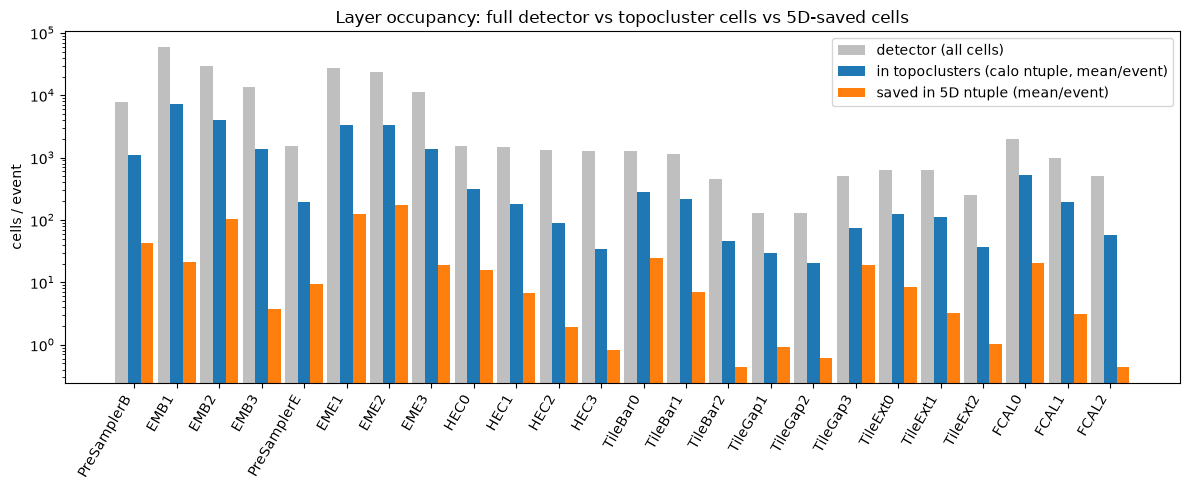

In [5]:
x = np.arange(NSAMP)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.3, det_counts, 0.3, label="detector (all cells)", color="0.75")
ax.bar(x, counts_topo_mean, 0.3, label="in topoclusters (calo ntuple, mean/event)", color="tab:blue")
ax.bar(x + 0.3, counts_5d_mean, 0.3, label="saved in 5D ntuple (mean/event)", color="tab:orange")
ax.set_yscale("log")
ax.set_xticks(x, names, rotation=60, ha="right")
ax.set_ylabel("cells / event")
ax.set_title("Layer occupancy: full detector vs topocluster cells vs 5D-saved cells")
ax.legend()
plt.tight_layout()

### Occupancy *fraction* — the probability that a given cell of a layer appears

Dividing by the number of cells in the layer removes the layer-size effect and makes
the selection policy visible directly.

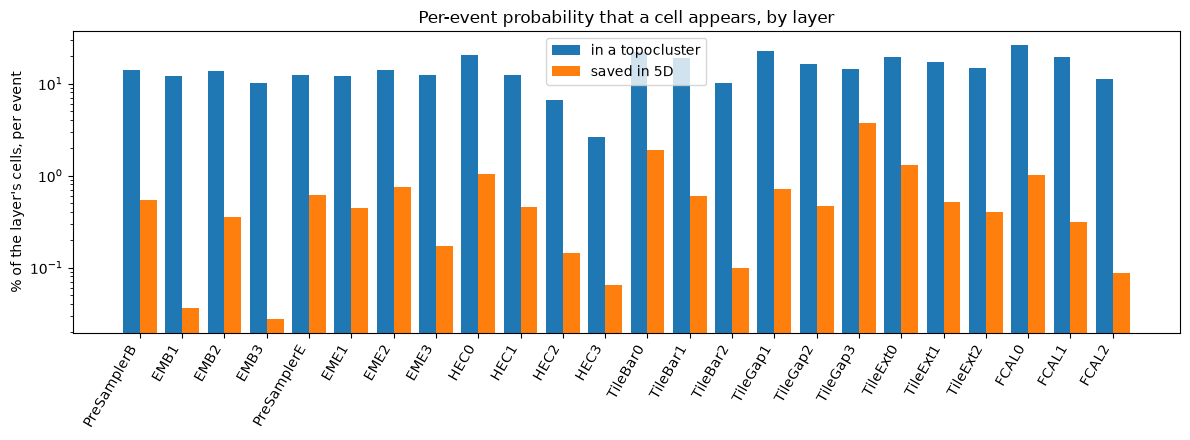

In [6]:
frac_topo = np.divide(counts_topo_mean, det_counts, out=np.zeros(NSAMP), where=det_counts > 0)
frac_5d = np.divide(counts_5d_mean, det_counts, out=np.zeros(NSAMP), where=det_counts > 0)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - 0.2, 100 * frac_topo, 0.4, label="in a topocluster", color="tab:blue")
ax.bar(x + 0.2, 100 * frac_5d, 0.4, label="saved in 5D", color="tab:orange")
ax.set_yscale("log")
ax.set_xticks(x, names, rotation=60, ha="right")
ax.set_ylabel("% of the layer's cells, per event")
ax.set_title("Per-event probability that a cell appears, by layer")
ax.legend()
plt.tight_layout()

## 2. Layer distribution: topocluster cells vs 5D-saved cells

Normalized to unit area: "given a saved/clustered cell, which layer is it in?"
The ratio panel is the per-layer bias factor of the 5D selection relative to
topoclusters.

OVER   TileGap3     5D/topo = 10.09
OVER   TileBar0     5D/topo = 3.41
OVER   TileExt0     5D/topo = 2.65
OVER   EME2         5D/topo = 2.10
OVER   HEC0         5D/topo = 1.98
OVER   PreSamplerE  5D/topo = 1.93
OVER   PreSamplerB  5D/topo = 1.54
OVER   FCAL0        5D/topo = 1.53
OVER   HEC1         5D/topo = 1.47
OVER   EME1         5D/topo = 1.47
OVER   TileBar1     5D/topo = 1.25
OVER   TileGap1     5D/topo = 1.23
OVER   TileExt1     5D/topo = 1.16
OVER   TileGap2     5D/topo = 1.14
OVER   TileExt2     5D/topo = 1.08
OVER   EMB2         5D/topo = 1.03
under  HEC3         5D/topo = 0.97
under  HEC2         5D/topo = 0.85
under  FCAL1        5D/topo = 0.63
under  EME3         5D/topo = 0.54
under  TileBar2     5D/topo = 0.38
under  FCAL2        5D/topo = 0.30
under  EMB1         5D/topo = 0.12
under  EMB3         5D/topo = 0.11


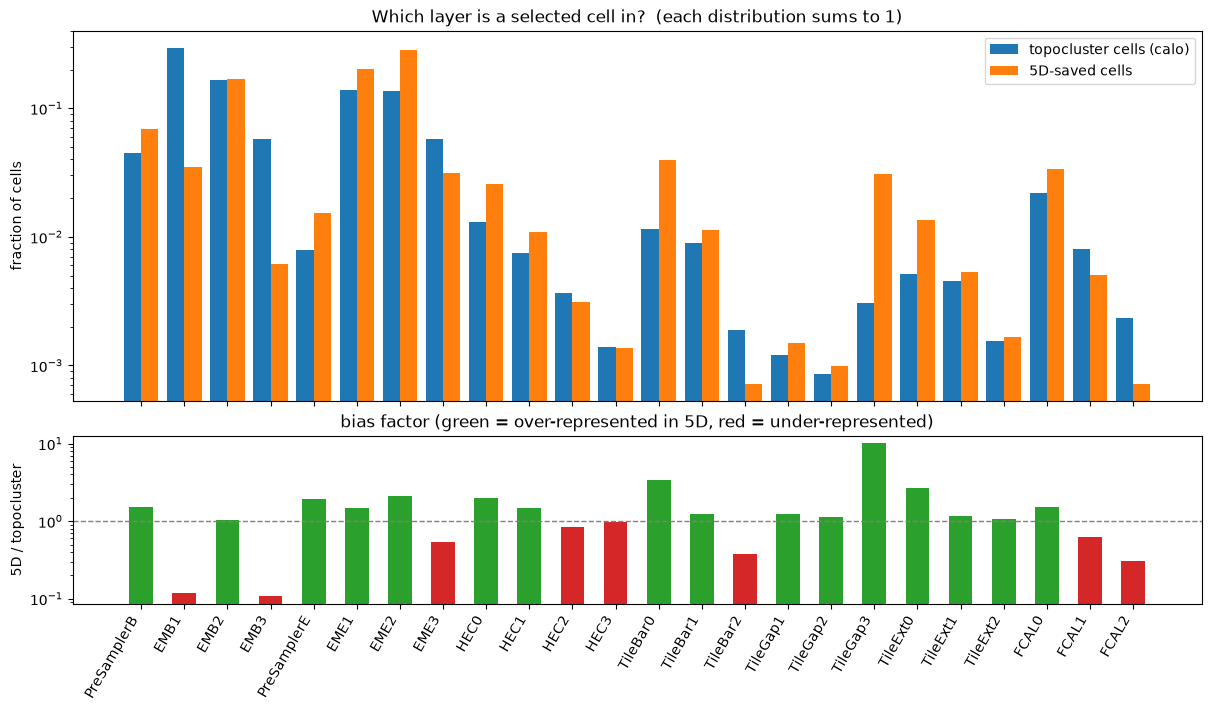

In [7]:
p_topo = counts_topo_mean / counts_topo_mean.sum()
p_5d = counts_5d_mean / counts_5d_mean.sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                               height_ratios=[2.2, 1], constrained_layout=True)
ax1.bar(x - 0.2, p_topo, 0.4, label="topocluster cells (calo)", color="tab:blue")
ax1.bar(x + 0.2, p_5d, 0.4, label="5D-saved cells", color="tab:orange")
ax1.set_yscale("log")
ax1.set_ylabel("fraction of cells")
ax1.set_title("Which layer is a selected cell in?  (each distribution sums to 1)")
ax1.legend()

ratio = np.divide(p_5d, p_topo, out=np.full(NSAMP, np.nan), where=p_topo > 0)
ax2.axhline(1.0, color="0.5", lw=1, ls="--")
ax2.bar(x, ratio, 0.55, color=np.where(np.nan_to_num(ratio) >= 1, "tab:green", "tab:red"))
ax2.set_yscale("log")
ax2.set_xticks(x, names, rotation=60, ha="right")
ax2.set_ylabel("5D / topocluster")
ax2.set_title("bias factor (green = over-represented in 5D, red = under-represented)")

for s in np.argsort(np.nan_to_num(ratio))[::-1]:
    if det_counts[s] and np.isfinite(ratio[s]):
        tag = "OVER " if ratio[s] > 1 else "under"
        print(f"{tag}  {names[s]:<12} 5D/topo = {ratio[s]:.2f}")

### Grouped by subdetector

In [8]:
groups = {"EM barrel (0-3)": range(0, 4), "EM endcap (4-7)": range(4, 8),
          "HEC (8-11)": range(8, 12), "Tile A/BC+C10 (12,13,15,18,19)": [12, 13, 15, 18, 19],
          "Tile D incl. D4 (14,16,20)": [14, 16, 20], "Tile E/crack scint (17)": [17],
          "FCAL (21-23)": range(21, 24)}
print(f"{'group':<32}{'det cells':>10}{'topo %':>9}{'5D %':>9}{'bias':>7}")
for g, ss in groups.items():
    ss = list(ss)
    pt, p5 = p_topo[ss].sum(), p_5d[ss].sum()
    print(f"{g:<32}{det_counts[ss].sum():>10}{100*pt:>8.1f}%{100*p5:>8.1f}%"
          f"{p5/pt if pt else float('nan'):>7.2f}")

group                            det cells   topo %     5D %   bias
EM barrel (0-3)                     109568    56.4%    28.0%   0.50
EM endcap (4-7)                      63744    33.9%    53.4%   1.57
HEC (8-11)                            5632     2.6%     4.1%   1.61
Tile A/BC+C10 (12,13,15,18,19)        3840     3.1%     7.1%   2.26
Tile D incl. D4 (14,16,20)             832     0.4%     0.3%   0.78
Tile E/crack scint (17)                512     0.3%     3.1%  10.09
FCAL (21-23)                          3524     3.2%     3.9%   1.21


## 3. What selection do the saved 5D cells actually satisfy?

The layer pattern above doesn't look object-driven. Checking the saved cells'
energy and significance directly reveals the actual selection.

over 100 events, 64862 saved cells:
  min Cell_e            = 0.500074 GeV   <- hard floor at 0.5 GeV
  min Cell_significance = 2.000116      <- hard floor at 2
  cells with E < 0      = 0            <- one-sided (positive) selection
  max |significance - E/totalNoise| = 6.1e-05   (significance IS E/totalNoise)


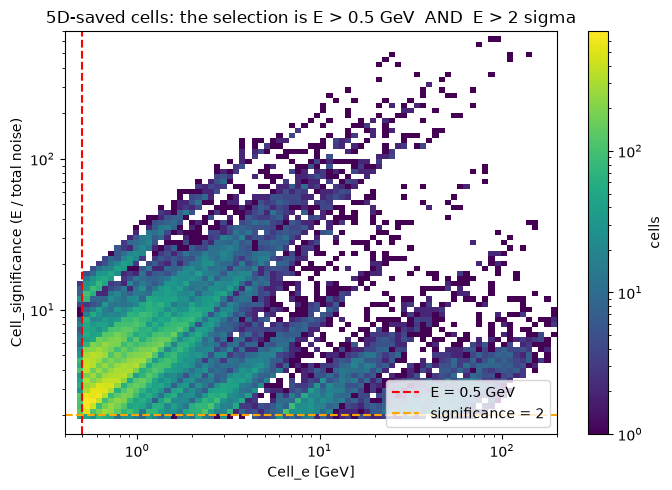

In [9]:
a5 = t5.arrays(["Cell_e", "Cell_significance", "Cell_totalNoise"], entry_stop=100)
e5 = ak.to_numpy(ak.flatten(a5["Cell_e"]))
sig5 = ak.to_numpy(ak.flatten(a5["Cell_significance"]))
noise5 = ak.to_numpy(ak.flatten(a5["Cell_totalNoise"]))

print(f"over 100 events, {len(e5)} saved cells:")
print(f"  min Cell_e            = {e5.min():.6f} GeV   <- hard floor at 0.5 GeV")
print(f"  min Cell_significance = {sig5.min():.6f}      <- hard floor at 2")
print(f"  cells with E < 0      = {(e5 < 0).sum()}            <- one-sided (positive) selection")
print(f"  max |significance - E/totalNoise| = {np.abs(sig5 - e5 / noise5).max():.2g}"
      f"   (significance IS E/totalNoise)")

fig, ax = plt.subplots(figsize=(7, 5))
h = ax.hist2d(e5, sig5, bins=[np.geomspace(0.4, 200, 80), np.geomspace(1.5, 700, 80)],
              norm="log", cmap="viridis")
ax.axvline(0.5, color="r", ls="--", lw=1.5, label="E = 0.5 GeV")
ax.axhline(2.0, color="orange", ls="--", lw=1.5, label="significance = 2")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Cell_e [GeV]"); ax.set_ylabel("Cell_significance (E / total noise)")
ax.set_title("5D-saved cells: the selection is E > 0.5 GeV  AND  E > 2 sigma")
fig.colorbar(h[3], label="cells"); ax.legend(loc="lower right")
plt.tight_layout()

In [10]:
# which of the two cuts is binding, per layer?
sampf = ak.to_numpy(ak.flatten(t5["Cell_sampling"].array(entry_stop=100))).astype(np.int64)
print(f"{'layer':<14}{'n saved':>8}{'min E [GeV]':>12}{'min signif':>11}   binding cut")
for s in range(NSAMP):
    m = sampf == s
    if not m.sum():
        continue
    mn_e, mn_s = e5[m].min(), sig5[m].min()
    binding = "significance = 2" if mn_s < 2.5 else "E = 0.5 GeV (low-noise layer -> eff. high-sigma cut)"
    print(f"{names[s]:<14}{m.sum():>8}{mn_e:>12.3f}{mn_s:>11.2f}   {binding}")

layer          n saved min E [GeV] min signif   binding cut
PreSamplerB       4638       0.500       2.00   significance = 2
EMB1              2093       0.500       6.03   E = 0.5 GeV (low-noise layer -> eff. high-sigma cut)
EMB2             10831       0.500       2.63   E = 0.5 GeV (low-noise layer -> eff. high-sigma cut)
EMB3               352       0.500       4.29   E = 0.5 GeV (low-noise layer -> eff. high-sigma cut)
PreSamplerE        993       0.792       2.00   significance = 2
EME1             13115       0.500       2.00   significance = 2
EME2             18570       0.500       2.00   significance = 2
EME3              2086       0.500       2.01   significance = 2
HEC0              1787       1.430       2.00   significance = 2
HEC1               705       0.558       2.00   significance = 2
HEC2               205       1.108       2.00   significance = 2
HEC3                93       0.903       2.00   significance = 2
TileBar0          2615       0.609       2.00   sign

## Conclusions

- **Scale of the difference**: topoclustering selects 24,147 +- 4,447 cells/event
  (12.9% of the detector's 187,652); the 5D ntuple saves 614 +- 220 (0.33%).
- **The empirical 5D selection is a per-cell threshold, not an object matching**:
  every saved cell has `E > 0.5 GeV` **and** `E > 2 x totalNoise`, positive energies
  only (min saved E = 0.500074 GeV, min significance = 2.000, zero E < 0 cells in
  100 events). Topoclustering, by contrast, is two-sided (|E| > 4/2/0 sigma seeding)
  and keeps every cell of a cluster regardless of its own energy.
- **The resulting layer bias** (ratio panel above):
  - Fine-granularity EM layers collapse: EMB1 holds ~30% of topocluster cells but
    3.5% of 5D cells (bias 0.12); EMB3 0.11. Small strip cells rarely reach 0.5 GeV —
    on low-noise strips the 0.5 GeV floor acts as an effective ~6 sigma cut (see the
    per-layer minimum-significance table).
  - Coarse, high-response layers survive or gain: EMB2 (1.03), EME2 (2.10),
    TileBar0 (3.41), and the Tile E/crack scintillators (TileGap3) are **x10**
    over-represented.
  - The endcap overtakes the barrel: EM endcap holds 53% of 5D cells vs 34% of
    topocluster cells (barrel: 28% vs 56%) — endcap cells see more energy per cell,
    so more pass an absolute threshold.
- **The nominal thinning recipe (e/gamma, muon, tau objects + Tile D cells) is not
  visible in these files**: Tile D is *under*-represented (bias 0.78; per-event
  occupancy 0.1% of D cells vs 10% in topoclusters — nothing like "always saved"),
  and no layer pattern suggests object windows. Either this production used a
  different (threshold-based) selection, or the thresholds dominate any object
  thinning so completely that the recipe leaves no visible trace.
- **Consequence for training on 5D cells**: the model sees a sparse, high-|eta|-,
  coarse-granularity-, high-energy-biased view of the calorimeter, and the strip
  layer that dominates topocluster granularity is essentially absent. Any
  topocluster-level task (e.g. reproducing cluster energies from cells) is
  structurally impossible from the 5D subset alone.

*Caveat*: the two files are different ttbar samples (possibly different pileup), so
the comparison is at the level of per-event averages; the threshold findings
(0.5 GeV / 2 sigma floors) are sample-independent statements about the 5D format.